In [27]:
from keras.models import load_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             roc_curve)
import pandas as pd
import ast
from FENtoTensor import fen_to_tensor, result_to_label, extract_fen_pairs
from like_sunfish import evaluate_sunfish_style
import numpy as np
from sklearn.model_selection import train_test_split

In [6]:
model = load_model('chess_error_model.h5')

In [ ]:
p2 = pd.read_csv("part2.csv")
data = p2.copy()

In [ ]:
if 'positions' in data.columns:
    data['fen_list'] = data['positions'].apply(ast.literal_eval)
else:
    print("Ошибка: не найдена колонка 'positions'")
    print("Доступные колонки:", data.columns.tolist())
    exit()

In [ ]:
all_pairs = []
all_labels = []

for idx, row in data.iterrows():
    fen_list = row['fen_list']
    result = row['result']
    
    label = result_to_label(result)
    pairs = extract_fen_pairs(fen_list)
    
    for current_fen, next_fen in pairs:
        all_pairs.append((current_fen, next_fen))
        all_labels.append(label)
    
    if idx % 1000 == 0:
        print(f"Обработано {idx} партий...")
    

Обработано 0 партий...
Обработано 1000 партий...
Обработано 2000 партий...
Обработано 3000 партий...
Обработано 4000 партий...
Обработано 5000 партий...
Обработано 6000 партий...
Обработано 7000 партий...
Обработано 8000 партий...
Обработано 9000 партий...
Обработано 10000 партий...
Обработано 11000 партий...
Обработано 12000 партий...
Обработано 13000 партий...
Обработано 14000 партий...
Обработано 15000 партий...
Обработано 16000 партий...
Обработано 17000 партий...
Обработано 18000 партий...
Обработано 19000 партий...
Обработано 20000 партий...
Обработано 21000 партий...
Обработано 22000 партий...
Обработано 23000 партий...
Обработано 24000 партий...
Обработано 25000 партий...
Обработано 26000 партий...
Обработано 27000 партий...
Обработано 28000 партий...
Обработано 29000 партий...
Обработано 30000 партий...
Обработано 31000 партий...
Обработано 32000 партий...
Обработано 33000 партий...
Обработано 34000 партий...
Обработано 35000 партий...
Обработано 36000 партий...
Обработано 370

In [ ]:
def is_mistake(current_fen, next_fen, threshold=-100):
    score_before = evaluate_sunfish_style(current_fen)
    score_after = evaluate_sunfish_style(next_fen)
    return (score_after - score_before) < threshold

In [ ]:
TEST_SIZE = 100000
limited_pairs = all_pairs[:TEST_SIZE]

error_labels = []
for i, (current_fen, next_fen) in enumerate(limited_pairs):
    is_err = is_mistake(current_fen, next_fen, -100)
    error_labels.append(is_err)
    
    if (i + 1) % 10000 == 0:
        print(f"Обработано {i+1}/{TEST_SIZE} пар...")

error_labels = np.array(error_labels).reshape(-1, 1)
print(f'Ошибок: {error_labels.sum()} / {len(error_labels)} ({error_labels.mean()*100:.1f}%)')

Обработано 10000/100000 пар...
Обработано 20000/100000 пар...
Обработано 30000/100000 пар...
Обработано 40000/100000 пар...
Обработано 50000/100000 пар...
Обработано 60000/100000 пар...
Обработано 70000/100000 пар...
Обработано 80000/100000 пар...
Обработано 90000/100000 пар...
Обработано 100000/100000 пар...
Ошибок: 11620 / 100000 (11.6%)


In [ ]:
indices = np.arange(len(limited_pairs))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=error_labels
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=error_labels[temp_idx]
)

test_labels = error_labels[test_idx].flatten()

In [ ]:
def data_generator(all_pairs, pair_indices, labels, batch_size=32, shuffle=False):
    num_samples = len(pair_indices)
    
    while True:
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            
            current_batch_indices = pair_indices[start_idx:end_idx]
            current_batch_labels = labels[start_idx:end_idx]
            
            # Преобразуем ТОЛЬКО этот батч в тензоры
            batch_X = np.array(
                [fen_to_tensor(limited_pairs[i][0]) for i in current_batch_indices],
                dtype=np.float32
            )
            batch_y = current_batch_labels.astype(np.float32).reshape(-1, 1)
            
            yield batch_X, batch_y

In [ ]:
BATCH_SIZE = 64
test_generator = data_generator(
    limited_pairs, test_idx, test_labels,
    batch_size=BATCH_SIZE, shuffle=False
)

test_steps = (len(test_idx) + BATCH_SIZE - 1) // BATCH_SIZE

In [ ]:
predictions_prob = model.predict(test_generator, steps=test_steps, verbose=1)
predictions_prob = predictions_prob[:len(test_idx)]  

predictions_binary = (predictions_prob >= 0.5).astype(int).flatten()

y_true = test_labels.flatten()

235/235 [==============================] - 2s 7ms/step


In [47]:
accuracy = accuracy_score(y_true, predictions_binary)
precision = precision_score(y_true, predictions_binary)
recall = recall_score(y_true, predictions_binary)
f1 = f1_score(y_true, predictions_binary)
auc = roc_auc_score(y_true, predictions_prob)

print(f'\n{"="*50}')
print(f'📊 МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ')
print(f'{"="*50}')
print(f'Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {auc:.4f}')
print(f'{"="*50}\n')


📊 МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ
Accuracy:  0.9034  (90.34%)
Precision: 0.7663
Recall:    0.2427
F1-score:  0.3686
ROC-AUC:   0.8475



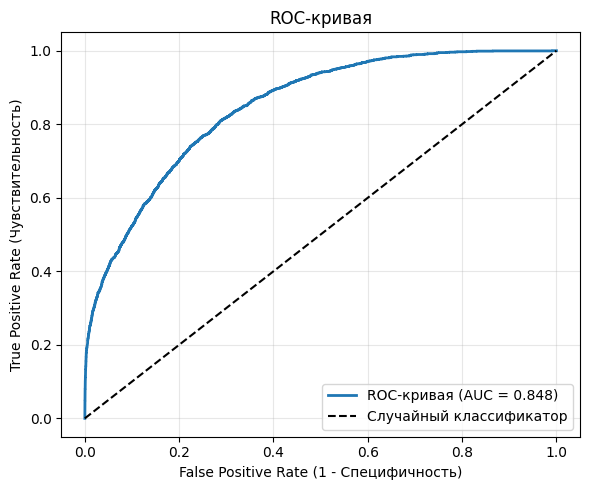

In [48]:
fpr, tpr, thresholds = roc_curve(y_true, predictions_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (1 - Специфичность)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()